<a href="https://colab.research.google.com/github/azharm2412/tugas-1-deep-learning-slp/blob/main/Tugas%201%20Single%20Layer%20Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nam:** Azhar Maulana    
**NIM:** 24/533487/PA/22582   

# Tugas 1 - Single Layer Perceptron (SLP) - Klasifikasi Biner Iris

Notebook ini mengimplementasikan Single Layer Perceptron (SLP) untuk klasifikasi biner antara Iris-setosa (kelas 0) dan Iris-versicolor(kelas 1), menggunakan 4 fitur: panjang & lebar sepal, panjang & lebar petal.

**Konfigurasi:**
- Data: 100 baris (50 setosa + 50 versicolor)
- Split: 40 data pertama tiap kelas → training (80 data), 10 data sisa tiap kelas → validation (20 data)
- Inisialisasi bobot & bias: 0.5 untuk semua
- Learning rate: 0.1, jumlah epoch: 5




## 1. Load & Persiapan Data

In [12]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/azharm2412//tugas-1-deep-learning-slp/refs/heads/main/data.csv'
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, header=None, names=column_names)

df['target'] = df['species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})

print(f"Total data: {len(df)} baris ({df['species'].value_counts().to_dict()})")
df.head()

Total data: 100 baris ({'Iris-setosa': 50, 'Iris-versicolor': 50})


,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


## 2. Split Data: Training vs Validation

In [13]:
setosa = df[df['species'] == 'Iris-setosa'].reset_index(drop=True)
versicolor = df[df['species'] == 'Iris-versicolor'].reset_index(drop=True)

train_setosa = setosa.iloc[:40]
val_setosa = setosa.iloc[40:]

train_versicolor = versicolor.iloc[:40]
val_versicolor = versicolor.iloc[40:]

train_df = pd.concat([train_setosa, train_versicolor]).reset_index(drop=True)
val_df = pd.concat([val_setosa, val_versicolor]).reset_index(drop=True)

feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_val = val_df[feature_cols].values
y_val = val_df['target'].values

print(f"Jumlah data training  : {len(X_train)}  {train_df['species'].value_counts().to_dict()}")
print(f"Jumlah data validation: {len(X_val)}  {val_df['species'].value_counts().to_dict()}")

Jumlah data training  : 80  {'Iris-setosa': 40, 'Iris-versicolor': 40}
Jumlah data validation: 20  {'Iris-setosa': 10, 'Iris-versicolor': 10}


## 3. Fungsi-Fungsi SLP

In [14]:
def resultSum(X, weight, bias, w_bias):
    resultSum = np.dot(X, weight) + (bias * w_bias)
    return resultSum

def activation(resultSum):
    aktivasi = 1 / (1 + math.exp(-resultSum))
    return aktivasi

def predict(f):
    if f > 0.5:
        return 1
    else:
        return 0

def error(f, target):
    error = pow((f - target), 2)
    return error

def dT(x, f, target):
    dt = 2 * (f - target) * (1 - f) * (f * x)
    return dt

def updateWeight(dt, weight, learning_rate):
    weight = weight - (learning_rate * dt)
    return weight

def updateBias(dt, bias, learning_rate):
    bias = bias - (learning_rate * dt)
    return bias

def akurasi(prediksi, target):
    TP = 0.0
    TN = 0.0
    FP = 0.0
    FN = 0.0
    for i in range(len(prediksi)):
        if target[i] == 1.0 and prediksi[i] == 1.0:
            TP = TP + 1.0
        elif target[i] == 1.0 and prediksi[i] == 0.0:
            FN = FN + 1.0
        elif target[i] == 0.0 and prediksi[i] == 1.0:
            FP = FP + 1.0
        elif target[i] == 0.0 and prediksi[i] == 0.0:
            TN = TN + 1.0
    total = TP + TN + FP + FN
    hitung_akurasi = (TP + TN) / total
    return TP, TN, FP, FN, total, hitung_akurasi


def train_one_epoch(X, y, weight, w_bias, bias, learning_rate):
    """Satu epoch training: bobot di-update tiap baris data."""
    list_error_data = []
    list_prediksi = []

    for i in range(len(X)):
        xi = X[i]
        target = y[i]

        z = resultSum(xi, weight, bias, w_bias)
        f = activation(z)
        pred = predict(f)

        e = error(f, target)
        list_error_data.append(e)
        list_prediksi.append(pred)

        for j in range(len(weight)):
            dt_w = dT(xi[j], f, target)
            weight[j] = updateWeight(dt_w, weight[j], learning_rate)

        dt_b = dT(bias, f, target)
        w_bias = updateBias(dt_b, w_bias, learning_rate)

    rata_error = sum(list_error_data) / len(list_error_data)
    TP, TN, FP, FN, total, rata_akurasi = akurasi(list_prediksi, y)

    return weight, w_bias, rata_error, TP, TN, FP, FN, total, rata_akurasi


def evaluate(X, y, weight, w_bias, bias):
    """Forward pass tanpa update bobot dipakai untuk data VALIDATION."""
    list_error_data = []
    list_prediksi = []
    for i in range(len(X)):
        z = resultSum(X[i], weight, bias, w_bias)
        f = activation(z)
        pred = predict(f)
        list_error_data.append(error(f, y[i]))
        list_prediksi.append(pred)
    rata_error = sum(list_error_data) / len(list_error_data)
    TP, TN, FP, FN, total, rata_akurasi = akurasi(list_prediksi, y)
    return rata_error, TP, TN, FP, FN, total, rata_akurasi

## 4. Proses Training (5 Epoch)

In [15]:
n_fitur = X_train.shape[1]
weight = np.full(n_fitur, 0.5)
w_bias = 0.5
bias = 1.0
learning_rate = 0.1
epochs = 5

rows_train = []
rows_val = []

for epoch in range(epochs):
    weight, w_bias, train_error, TP, TN, FP, FN, total, train_akurasi = train_one_epoch(
        X_train, y_train, weight, w_bias, bias, learning_rate
    )
    rows_train.append([epoch+1, train_error, TP, TN, FP, FN, total, train_akurasi])

    val_error, vTP, vTN, vFP, vFN, vtotal, val_akurasi = evaluate(X_val, y_val, weight, w_bias, bias)
    rows_val.append([epoch+1, val_error, vTP, vTN, vFP, vFN, vtotal, val_akurasi])

    print(f"Epoch {epoch+1}/{epochs} | Train -> Error: {train_error:.6f}  Akurasi: {train_akurasi:.4f}"
          f" | Val -> Error: {val_error:.6f}  Akurasi: {val_akurasi:.4f}")

list_train_error  = [r[1] for r in rows_train]
list_train_akurasi = [r[7] for r in rows_train]
list_val_error    = [r[1] for r in rows_val]
list_val_akurasi  = [r[7] for r in rows_val]

Epoch 1/5 | Train -> Error: 0.449889  Akurasi: 0.5250 | Val -> Error: 0.328951  Akurasi: 0.5000
Epoch 2/5 | Train -> Error: 0.037452  Akurasi: 0.9500 | Val -> Error: 0.247289  Akurasi: 0.5000
Epoch 3/5 | Train -> Error: 0.024372  Akurasi: 0.9750 | Val -> Error: 0.175892  Akurasi: 0.5000
Epoch 4/5 | Train -> Error: 0.017357  Akurasi: 0.9750 | Val -> Error: 0.119381  Akurasi: 0.8500
Epoch 5/5 | Train -> Error: 0.012740  Akurasi: 0.9875 | Val -> Error: 0.081581  Akurasi: 1.0000


## 5. Ringkasan Hasil per Epoch

In [18]:
cols = ['Epoch', 'Average MSE', 'TP', 'TN', 'FP', 'FN', 'Total', 'Akurasi']

summary_train = pd.DataFrame(rows_train, columns=cols)
summary_train['Akurasi'] = summary_train['Akurasi'].apply(lambda a: f"{a:.2%}")

summary_val = pd.DataFrame(rows_val, columns=cols)
summary_val['Akurasi'] = summary_val['Akurasi'].apply(lambda a: f"{a:.2%}")

print("Tabel 1. Ringkasan Training (per Epoch)")
display(summary_train)

print("\nTabel 2. Ringkasan Validation (per Epoch)")
display(summary_val)

Tabel 1. Ringkasan Training (per Epoch)


,Epoch,Average MSE,TP,TN,FP,FN,Total,Akurasi
0,1,0.449889,39.0,3.0,37.0,1.0,80.0,52.50%
1,2,0.037452,38.0,38.0,2.0,2.0,80.0,95.00%
2,3,0.024372,39.0,39.0,1.0,1.0,80.0,97.50%
3,4,0.017357,39.0,39.0,1.0,1.0,80.0,97.50%
4,5,0.012740,39.0,40.0,0.0,1.0,80.0,98.75%



Tabel 2. Ringkasan Validation (per Epoch)


,Epoch,Average MSE,TP,TN,FP,FN,Total,Akurasi
0,1,0.328951,10.0,0.0,10.0,0.0,20.0,50.00%
1,2,0.247289,10.0,0.0,10.0,0.0,20.0,50.00%
2,3,0.175892,10.0,0.0,10.0,0.0,20.0,50.00%
3,4,0.119381,10.0,7.0,3.0,0.0,20.0,85.00%
4,5,0.081581,10.0,10.0,0.0,0.0,20.0,100.00%


## 6. Visualisasi

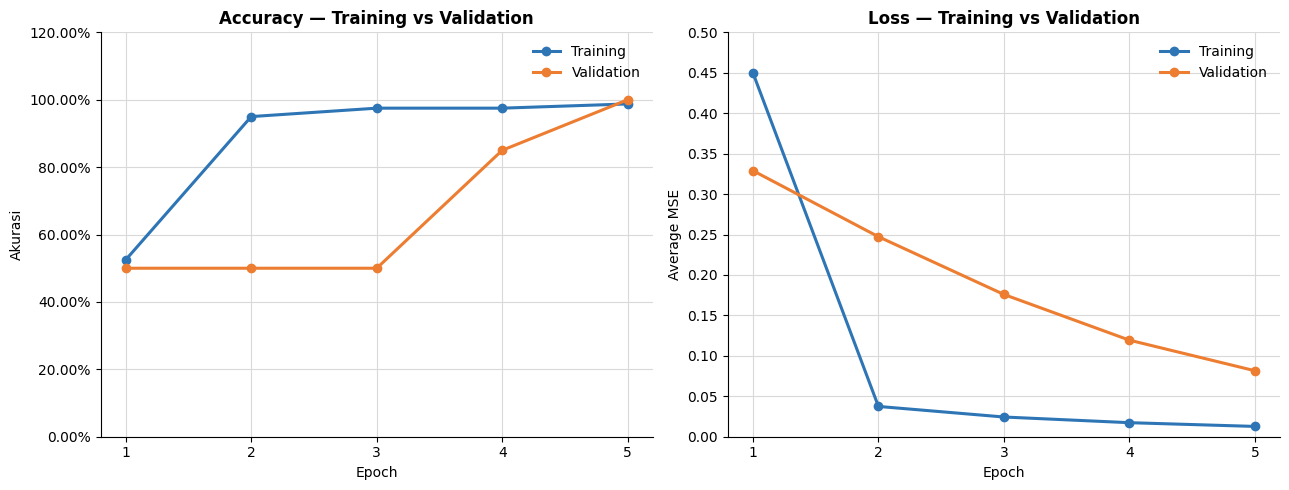

In [17]:
import numpy as np

TRAIN_COLOR = '#2E75B6'
VAL_COLOR = '#ED7D31'
epoch_range = range(1, epochs + 1)

def style_ax(ax, title, ylabel, y_ticks=None, percent=False, num_decimals=2):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(epoch_range))
    ax.grid(True, color='#D9D9D9', linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_ylim(y_ticks[0], y_ticks[-1])
    if percent:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
    else:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.{num_decimals}f}'))
    ax.legend(frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# accuracy: training vs validation
axes[0].plot(epoch_range, list_train_akurasi, marker='o', color=TRAIN_COLOR, linewidth=2.2, label='Training')
axes[0].plot(epoch_range, list_val_akurasi, marker='o', color=VAL_COLOR, linewidth=2.2, label='Validation')
style_ax(axes[0], 'Accuracy — Training vs Validation', 'Akurasi',
         y_ticks=np.arange(0, 1.21, 0.2), percent=True)

# loss: training vs validation
axes[1].plot(epoch_range, list_train_error, marker='o', color=TRAIN_COLOR, linewidth=2.2, label='Training')
axes[1].plot(epoch_range, list_val_error, marker='o', color=VAL_COLOR, linewidth=2.2, label='Validation')
style_ax(axes[1], 'Loss — Training vs Validation', 'Average MSE',
         y_ticks=np.arange(0, 0.51, 0.05), num_decimals=2)

plt.tight_layout()
plt.savefig('accuracy_loss_charts.png', dpi=150, bbox_inches='tight')
plt.show()